<a href="https://colab.research.google.com/github/VIVEK0CHINMAY/DATA-MINING/blob/main/LAB_3_Apriori_histogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HISTOGRAM ANALYSIS**

### HISTOGRAM WITH SINGLETON SET

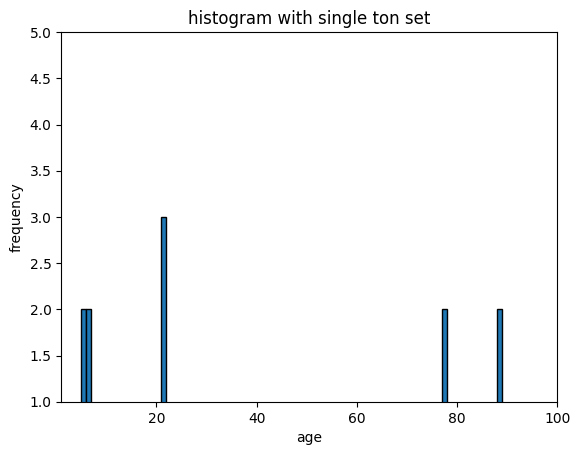

In [1]:
import matplotlib.pyplot as plt
age=[5,5,6,6,77,77,88,88,21,21,21]
plt.hist(age,bins=range(min(age),max(age)+2),edgecolor="black")
plt.title("histogram with single ton set")
plt.xlabel("age")
plt.ylabel("frequency")
plt.xlim(1,100)
plt.ylim(1,5)
plt.show()

### HISTOGRAM WITH SINGLETON SET

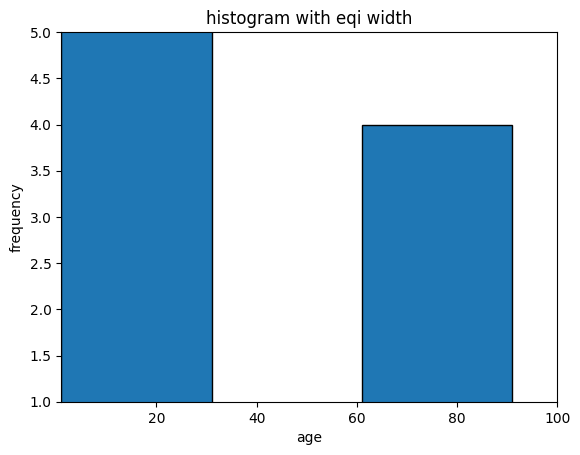

In [2]:
plt.hist(age,bins=[1,31,61,91],edgecolor="black")
plt.title("histogram with eqi width")
plt.xlabel("age")
plt.ylabel("frequency")
plt.xlim(1,100)
plt.ylim(1,5)
plt.show()

# **APRIORI**

In [4]:
!pip install mlxtend

In [3]:
import numpy as np
import pandas as pd
from  mlxtend.preprocessing import TransactionEncoder
from mlxtend .frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
df=pd.read_csv("/content/drive/MyDrive/Groceries_dataset.csv")
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [14]:
basket=df.groupby(['Member_number','Date'])['itemDescription'].apply(list)
transactions=basket.tolist()
transactions

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['sausage', 'rolls/buns'],
 ['root vegetables', 'detergent'],
 ['frozen meals', 'dental care'],
 ['rolls/buns', 'rolls/buns'],
 ['dish cleaner', 'cling film/bags'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'hygiene articles'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['rolls/buns', 'red/blush wine', 'chocolate'],
 ['other vegetables', 'shopping bags'],
 ['whole milk', 'chocolate', 'packaged fruit/vegetables', 'rolls/buns'],
 ['root vegetables', 'whole milk'

### Step 2: One hot coding to transform data into true/false format


In [16]:
te=TransactionEncoder()
te_array=te.fit(transactions).transform(transactions)
df_encoded=pd.DataFrame(te_array,columns=te.columns_)

### Step 3:Apriori algorithm

In [24]:
frequen_itemsets=apriori(df_encoded,min_support=0.01,use_colnames=True)
print("Total Frequent Itemsets:",frequen_itemsets.shape[0])

Total Frequent Itemsets: 69


### Step 4: Visualize most popular items

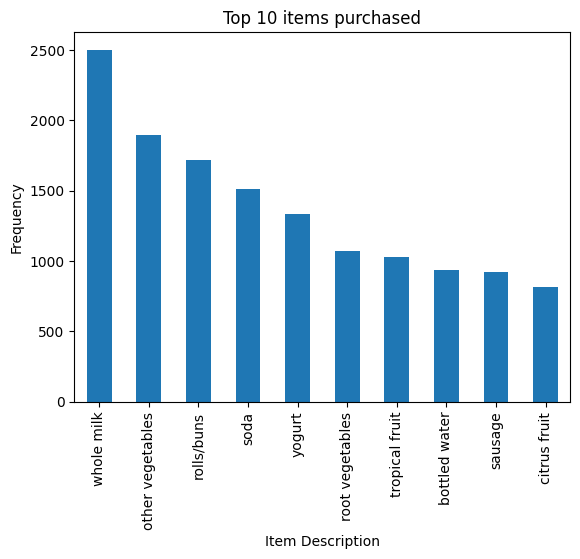

In [25]:
import matplotlib.pyplot as plt
top_items=df['itemDescription'].value_counts().head(10)
top_items.plot(kind='bar',title='Top 10 items purchased')
plt.xlabel('Item Description')
plt.ylabel('Frequency')
plt.show()

### Step 5: Association generate association rule

In [27]:
rules=association_rules(frequen_itemsets,metric='confidence',min_threshold=0.1)
rules=rules[rules['antecedents'].apply(lambda x:len(x)>=1) & rules['consequents'].apply(lambda x:len(x)>=1)]
print("Association rules:",rules.shape[0])
rules[['antecedents','consequents','support','confidence','lift']].head(5)

Association rules: 4


,antecedents,consequents,support,confidence,lift
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
2,(soda),(whole milk),0.011629,0.119752,0.758296
3,(yogurt),(whole milk),0.011161,0.129961,0.822940


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------